# Introduction to Cosmological Simulations

This tutorial introduces you to working with data from cosmological hydrodynamical simulations. We'll use the IllustrisTNG suite as our example, but the concepts apply broadly to other simulations.

---

## What are cosmological simulations?

Cosmological simulations model the evolution of the Universe from shortly after the Big Bang to the present day. They follow the gravitational collapse of dark matter and the complex physics of baryonic matter (gas, stars, and black holes) to produce populations of galaxies and large-scale structure.

### Types of simulations

| Type | Description | Examples |
|------|-------------|----------|
| **N-body (dark matter only)** | Follows only gravitational dynamics of collisionless dark matter particles | Millennium |
| **Hydrodynamical** | Includes gas physics, star formation, and feedback processes | IllustrisTNG, EAGLE |
| **Semi-analytic models** | Applies analytic prescriptions for baryons on top of N-body merger trees | L-Galaxies, GALFORM |

Modern hydrodynamical simulations like IllustrisTNG include gravity acting on dark matter and baryons, hydrodynamics governing gas flows, radiative cooling allowing gas to condense, star formation converting dense gas into stellar particles, stellar feedback from supernovae and stellar winds, black hole growth and AGN feedback, and magnetic fields.

### Simulation codes

Different simulations use different numerical methods to solve the equations of hydrodynamics:

| Method | Description | Codes |
|--------|-------------|-------|
| **SPH** (Smoothed Particle Hydrodynamics) | Lagrangian; gas represented by particles with smoothing kernels | GADGET, SWIFT |
| **AMR** (Adaptive Mesh Refinement) | Eulerian; gas on a grid that refines in dense regions | RAMSES, ENZO |
| **Moving mesh** | Hybrid; unstructured mesh that moves with the flow | AREPO |

IllustrisTNG uses the AREPO code with a moving Voronoi mesh, which combines advantages of both Lagrangian and Eulerian approaches.

---

## Simulation outputs and post-processing

### Raw outputs: Snapshots

As a simulation runs, it periodically writes out **snapshots** — complete dumps of all particle data at a single point in time. Each snapshot contains positions, velocities, masses, and other properties for every resolution element (particle or cell) in the simulation.

### Post-processing: Finding structures

Raw particle data isn't directly useful for studying galaxies — we first need to identify which particles belong to which structures. This is done by **structure finders** (also called halo finders), which are run as a post-processing step after the simulation completes.

The output of structure finding is stored in the **group catalog** (or halo catalog), which contains pre-computed properties for all identified halos and galaxies.

### Structure finding algorithms

Different algorithms identify structures in different ways: most structure finders begin with friends-of-friends (FOF) halos and then identify  substruture within them:

| Algorithm | Method | Used by |
|-----------|--------|--------|
| **Friends-of-Friends (FoF)** | Links particles closer than a linking length (typically 0.2× mean separation) | Most simulations (for halos) |
| **SUBFIND** | Finds gravitationally bound substructures within FoF groups | IllustrisTNG, EAGLE |
| **ROCKSTAR** | Phase-space based | Bolshoi, MultiDark |
| **VELOCIraptor** | Phase-space based | EAGLE, FLAMINGO |
| **HBT+** | Tracks subhalos across time using merger trees | COLIBRE |

The choice of structure finder affects which particles are assigned to which objects, particularly in crowded environments like galaxy clusters. This is important to keep in mind when comparing results across different simulations.

### Other post-processing products

Beyond structure finding, simulations often provide additional post-processed data including **merger trees** (linking objects across snapshots to track their evolution).

---

## Key terminology

| Term | Definition |
|------|------------|
| **Snapshot** | A complete dump of all particle data at a single point in time |
| **Particle/cell** | A resolution element representing dark matter, gas, stars, or black holes |
| **Halo** | A gravitationally bound dark matter structure (found by FoF) |
| **Subhalo** | A self-bound substructure within a halo, typically hosting a galaxy |
| **Group catalog** | Pre-computed properties of all halos and subhalos at each snapshot |

---

## Setup

First, let's import the libraries we'll need.

In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Ellipse
import h5py
from astropy.cosmology import Planck15
from astropy import units as u
from scipy.interpolate import interp1d

---

# Part 1: Accessing Simulation Data

Large simulations produce datasets typically of tens of terabytes. Downloading entire simulations is impractical for most users. The TNG project provides a **web-based API** that allows you to query metadata about each simulation, download specific fields from the group catalog, and request particle cutouts for individual objects.

This approach is much more efficient than downloading raw files, especially when you only need data for a handful of objects.

### Setting up API access

>You will need to register for an account at [tng-project.org](https://www.tng-project.org) and obtain an API key.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — edit these variables before running the notebook
# ─────────────────────────────────────────────────────────────────────────────

# Your IllustrisTNG API key.  Register at https://www.tng-project.org/users/register/
API_KEY = 'YOUR_API_KEY_HERE'

# Simulation to use, e.g.:
#   'TNG-Cluster', 'TNG300-1', 'TNG100-1', 'TNG50-1', 'TNG100-2', ...
SIM_NAME = 'TNG-Cluster'

# Snapshot number.  Snapshot 99 = z = 0 for most TNG runs.
SNAP = 99

# Halo selection: only halos above this mass (Msun/h) are considered.
MASS_THRESHOLD = 1e14   # Msun/h

# Which halo to analyse, by rank in the mass-sorted list (1 = most massive).
SELECTED_RANK = 230

# Redshift at which to observe the object for the surface brightness section.
Z_OBS = 0.05

# ── GitHub backup ─────────────────────────────────────────────────────────────
# If a TNG API download fails, the notebook will try to fetch the file from
# this GitHub repository instead.  Set this to the raw-content base URL of
# your backup repo, e.g.:
#   'https://raw.githubusercontent.com/YOUR_USERNAME/YOUR_REPO/main/backup_data/'
# Leave as None to disable the fallback entirely.
GITHUB_BACKUP_BASE_URL = 'https://github.com/garrethmartin/Leiden_sims_workshop/tree/main/Backup_files'

# ─────────────────────────────────────────────────────────────────────────────
baseUrl = 'https://www.tng-project.org/api/'
headers = {'api-key': API_KEY}

print("Configuration:")
print(f"  Simulation     : {SIM_NAME}")
print(f"  Snapshot       : {SNAP}")
print(f"  Mass threshold : {MASS_THRESHOLD:.0e} Msun/h")
print(f"  Selected rank  : {SELECTED_RANK}")
print(f"  z_obs          : {Z_OBS}")
print(f"  GitHub backup  : {GITHUB_BACKUP_BASE_URL or 'none'}")


Configuration:
  Simulation     : TNG-Cluster
  Snapshot       : 99
  Mass threshold : 1e+14 Msun/h
  Selected rank  : 230
  z_obs          : 0.05
  GitHub backup  : https://github.com/garrethmartin/Leiden_sims_workshop/tree/main/Backup_files


We'll define a helper function that handles API requests. It returns JSON for metadata queries, or downloads and saves HDF5 files for data requests.

In [3]:
import os

def get(path, params=None):
    """
    Make a TNG API request.
    Returns parsed JSON for metadata queries, or saves and returns the local
    filename for HDF5/binary file downloads.
    """
    r = requests.get(path, params=params, headers=headers)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json()

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split('filename=')[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename

    return r


def get_with_backup(path, params=None, backup_filename=None):
    """
    Wrapper around get() that falls back to a GitHub backup if the TNG API
    request fails (network error, HTTP error, or empty file).

    Parameters
    ----------
    path            : full TNG API URL
    params          : optional query-parameter dict
    backup_filename : filename within GITHUB_BACKUP_BASE_URL to retrieve
                      if the primary download fails.  Pass None to skip
                      the fallback for this call.

    Returns
    -------
    Parsed JSON dict (for metadata) or local filename string (for files).
    """
    try:
        result = get(path, params=params)
        # For file downloads, verify the result is a non-empty file
        if isinstance(result, str) and os.path.isfile(result):
            if os.path.getsize(result) == 0:
                raise ValueError(f"Downloaded file '{result}' is empty.")
        return result

    except Exception as primary_err:
        print(f"\n  Primary download failed: {primary_err}")

        if GITHUB_BACKUP_BASE_URL is None:
            print("   No GITHUB_BACKUP_BASE_URL configured — re-raising original error.")
            raise

        if backup_filename is None:
            print("   No backup_filename supplied for this call — re-raising original error.")
            raise

        backup_url = GITHUB_BACKUP_BASE_URL.rstrip('/') + '/' + backup_filename
        print(f"   Attempting GitHub backup: {backup_url}")

        r = requests.get(backup_url)
        r.raise_for_status()

        if r.headers.get('content-type', '').startswith('application/json'):
            print("   Loaded JSON from backup.")
            return r.json()

        with open(backup_filename, 'wb') as f:
            f.write(r.content)
        print(f"   Saved backup file to '{backup_filename}'.")
        return backup_filename


### Exploring available simulations

The IllustrisTNG project includes multiple simulations at different resolutions and box sizes. Let's see what's available.

In [4]:
# List all available simulations
sims = get(baseUrl)

print(f"\nTotal simulations available: {len(sims['simulations'])}\n")
print(f"{'Name':<25} {'N_snapshots':>12} {'URL'}")
print("-"*70)

for sim in sims['simulations']:
    print(f"{sim['name']:<25} {sim['num_snapshots']:>12} {sim['url']}")


Total simulations available: 66

Name                       N_snapshots URL
----------------------------------------------------------------------
Illustris-1                        134 http://www.tng-project.org/api/Illustris-1/
Illustris-1-Dark                   136 http://www.tng-project.org/api/Illustris-1-Dark/
Illustris-2                        136 http://www.tng-project.org/api/Illustris-2/
Illustris-2-Dark                   136 http://www.tng-project.org/api/Illustris-2-Dark/
Illustris-3                        136 http://www.tng-project.org/api/Illustris-3/
Illustris-3-Dark                   136 http://www.tng-project.org/api/Illustris-3-Dark/
TNG100-1                           100 http://www.tng-project.org/api/TNG100-1/
TNG100-1-Dark                      100 http://www.tng-project.org/api/TNG100-1-Dark/
TNG100-2                           100 http://www.tng-project.org/api/TNG100-2/
TNG100-2-Dark                      100 http://www.tng-project.org/api/TNG100-2-Dark/
TNG100-3 

### About the selected simulation

The cell below fetches metadata for whichever simulation you set as `SIM_NAME`.
Different simulations vary considerably in box size, resolution, and the objects
they contain — TNG-Cluster consists of 352 zoom simulations centred on massive
clusters, while TNG300-1 is a uniform-resolution periodic box of side 300 Mpc/h.
The metadata printout will tell you the key parameters.


In [5]:
# Get simulation metadata
sim_meta = get(baseUrl + SIM_NAME + '/')

print(f"{'Parameter':<30} {'Value'}")
print("-"*50)
for key, value in sorted(sim_meta.items()):
    if key not in ['snapshots', 'files', 'checksums']:
        if isinstance(value, float):
            print(f"{key:<30} {value:.6g}")
        else:
            print(f"{key:<30} {value}")


Parameter                      Value
--------------------------------------------------
boxsize                        680000
child_simulations              []
cosmology                      Planck2015
description                    Main high-resolution TNG-Cluster simulation suite (virtual box), with the full fiducial TNG physics model.
filesize_ctrees                0
filesize_ics                   0
filesize_lhalotree             6.55544e+11
filesize_simulation            8.13203e+08
filesize_sublink               1.43974e+12
has_blackholes                 True
has_cooling                    True
has_ctrees                     False
has_fof                        True
has_lhalotree                  True
has_rockstar                   False
has_starformation              True
has_subfind                    True
has_sublink                    True
has_winds                      True
hubble                         0.6774
is_subbox                      False
is_uniform                  

---

## Understanding snapshots

Simulations evolve the Universe forward in time using small timesteps. Periodically, the code writes out a **snapshot**. Key points:

- **Snapshot number** increases with cosmic time (snap 0 is the earliest output, snap 99 is z=0 for TNG)
- Not all snapshots contain the same data — "mini" snapshots may have fewer fields

In [6]:
# List all snapshots for the selected simulation
snapshots = get(sim_meta['snapshots'])

print(f"Total snapshots: {len(snapshots)}\n")
print(f"{'Snap':>6} {'Redshift':>10} {'a':>10} {'N_subhalos':>12}")
print("-"*42)

for snap_entry in snapshots[::5]:  # every 5th snapshot
    a = 1.0 / (1.0 + snap_entry['redshift'])
    print(f"{snap_entry['number']:>6} {snap_entry['redshift']:>10.4f} {a:>10.4f} "
          f"{snap_entry['num_groups_subfind']:>12,}")


Total snapshots: 100

  Snap   Redshift          a   N_subhalos
------------------------------------------
     0    20.0465     0.0475          865
     5     9.3888     0.0963    1,716,146
    10     7.2363     0.1214    6,605,524
    15     5.5298     0.1531   13,196,466
    20     4.1768     0.1932   18,030,432
    25     3.0081     0.2495   19,500,215
    30     2.3161     0.3016   18,945,554
    35     1.8227     0.3543   17,925,374
    40     1.4955     0.4007   16,972,332
    45     1.2063     0.4533   15,946,347
    50     0.9973     0.5007   15,114,540
    55     0.8167     0.5504   14,340,252
    60     0.6761     0.5966   13,703,864
    65     0.5464     0.6467   13,094,952
    70     0.4403     0.6943   12,583,427
    75     0.3479     0.7419   12,129,947
    80     0.2613     0.7928   11,700,734
    85     0.1804     0.8472   11,294,222
    90     0.1099     0.9010   10,935,653
    95     0.0485     0.9537   10,625,696


---

# Part 2: The Group Catalog

Raw particle data is useful, but often we want to work with **galaxies** and **halos** rather than individual particles. The **group catalog** provides pre-computed properties for all structures identified using the halo finder.

### Halos vs Subhalos

| Halos (FoF Groups) | Subhalos (SUBFIND Groups) |
|--------------------|--------------------------|
| Entire dark matter structure | Self-bound substructures |
| Found by Friends-of-Friends linking | Found by SUBFIND within each FoF group |

The **central subhalo** is the most massive subhalo in a halo, typically sitting at the potential minimum. **Satellite subhalos** orbit within the larger halo.

### Common mass definitions

- **M200c**: Mass within a sphere where mean density = 200× critical density
- **M500c**: Mass within a sphere where mean density = 500× critical density (common in X-ray studies)
- **FoF mass**: Total mass of all linked particles (no spherical aperture)

### Selecting a snapshot

We work with the snapshot set by `SNAP` in the configuration cell (default 99,
which corresponds to z = 0 for most TNG runs).  Adjust `SNAP` to study the
simulation at a different epoch.


In [7]:
# Get snapshot metadata
snap_info = get(baseUrl + f'{SIM_NAME}/snapshots/{SNAP}/')

print(f"Snapshot {SNAP} in {SIM_NAME}:")
print(f"  Redshift              : {snap_info['redshift']:.4f}")
print(f"  Number of FoF halos   : {snap_info['num_groups_fof']:,}")
print(f"  Number of subhalos    : {snap_info['num_groups_subfind']:,}")
print(f"  Number of star particles: {snap_info['num_stars']:,}")

# Cosmic time at this snapshot (used later for stellar ages)
t_now = Planck15.age(snap_info['redshift']).to(u.Gyr).value
print(f"  Cosmic time           : {t_now:.2f} Gyr")


Snapshot 99 in TNG-Cluster:
  Redshift              : 0.0000
  Number of FoF halos   : 19,453,039
  Number of subhalos    : 10,378,451
  Number of star particles: 1,067,549,783
  Cosmic time           : 13.80 Gyr


### Downloading group catalog data

The API allows downloading specific fields from the group catalog. Let's get the halo masses (M200c) to select a cluster.

>The full list of available fields is documented at: https://www.tng-project.org/data/docs/specifications/#sec2

In [8]:
# Download Group_M_Crit200 for all FoF halos
print(f"Downloading Group_M_Crit200 for {SIM_NAME}, snapshot {SNAP}...")

groupcat_url = baseUrl + f'{SIM_NAME}/files/groupcat-{SNAP}/'
m200c_file = get_with_backup(
    groupcat_url,
    params={'Group': 'Group_M_Crit200'},
    backup_filename=f'groupcat-{SIM_NAME}-{SNAP}-M200c.hdf5'
)

print(f"Downloaded: {m200c_file}")


Downloaded: fof_subhalo_tab_099.Group.Group_M_Crit200.hdf5


In [9]:
# Read the data
with h5py.File(m200c_file, 'r') as f:
    m200c = f['Group']['Group_M_Crit200'][:]

# Convert to Msun/h (data is stored in units of 10^10 Msun/h)
m200c_msun = m200c * 1e10

print(f"Total halos: {len(m200c_msun):,}")

Total halos: 19,453,039


### Visualising the halo mass function

Let's plot the cumulative halo mass function to see the distribution of halo masses.

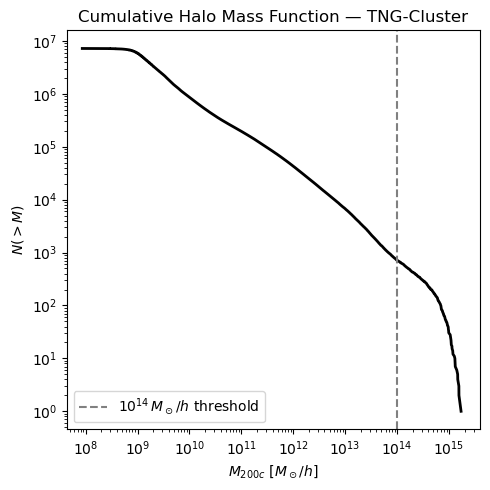

In [10]:
# Plot cumulative halo mass function
m200c_nonzero = m200c_msun[m200c_msun > 0]
sorted_masses = np.sort(m200c_nonzero)[::-1]
n_greater = np.arange(1, len(sorted_masses) + 1)

fig, ax = plt.subplots(figsize=(5, 5))
ax.loglog(sorted_masses, n_greater, 'k-', lw=2)
ax.axvline(MASS_THRESHOLD, color='grey', ls='--',
           label=rf'$10^{{{np.log10(MASS_THRESHOLD):.0f}}}\,M_\odot/h$ threshold')
ax.set_xlabel(r'$M_{200c}\ [M_\odot/h]$')
ax.set_ylabel(r'$N(>M)$')
ax.set_title(f'Cumulative Halo Mass Function — {SIM_NAME}')
ax.set_xlim(sorted_masses.min() * 0.5, None)
ax.legend(loc='lower left')
plt.tight_layout()


---

# Part 3: Selecting and Loading a Cluster

Now let's select a specific cluster to analyse. We'll pick one from our mass-selected sample.

### Finding massive halos

In [11]:
# Find halos above the mass threshold, sorted by mass
massive_halos = pd.Series(m200c_msun).loc[lambda x: x > MASS_THRESHOLD].sort_values(ascending=False)

massive_masses  = massive_halos.values
massive_indices = massive_halos.index.values

print(f"Found {len(massive_indices)} halos with M200c > 10^{np.log10(MASS_THRESHOLD):.0f} Msun/h")
print(f"  Most massive : {massive_masses[0]:.2e} Msun/h")
print(f"  Least massive: {massive_masses[-1]:.2e} Msun/h")


Found 715 halos with M200c > 10^14 Msun/h
  Most massive : 1.71e+15 Msun/h
  Least massive: 1.01e+14 Msun/h


### Selecting a halo

We pick a halo by its rank in the mass-sorted list, controlled by `SELECTED_RANK`
in the configuration cell (1 = most massive).


In [12]:
# Select a halo by rank (1 = most massive)
if SELECTED_RANK > len(massive_indices):
    raise ValueError(
        f"SELECTED_RANK ({SELECTED_RANK}) exceeds the number of halos above the "
        f"mass threshold ({len(massive_indices)}).  "
        f"Lower SELECTED_RANK or MASS_THRESHOLD and re-run."
    )

selected_halo_id = massive_indices[SELECTED_RANK - 1]
selected_mass    = massive_masses[SELECTED_RANK - 1]

print(f"Selected halo:")
print(f"  Rank    : {SELECTED_RANK} of {len(massive_indices)}")
print(f"  Halo ID : {selected_halo_id}")
print(f"  M200c   : {selected_mass:.3e} Msun/h")


Selected halo:
  Rank    : 230 of 715
  Halo ID : 12534413
  M200c   : 3.993e+14 Msun/h


### Loading halo properties

We can get detailed properties for our selected halo via the API.

In [13]:
# Get halo metadata
halo_meta = get(baseUrl + f'{SIM_NAME}/snapshots/{SNAP}/halos/{selected_halo_id}/')
halo_info = get(halo_meta['meta']['info'])

print(f"Halo {selected_halo_id} properties:")
print(f"  M200c             : {halo_info['Group_M_Crit200']*1e10:.2e} Msun/h")
print(f"  R200c             : {halo_info['Group_R_Crit200']:.1f} ckpc/h")
print(f"  Number of subhalos: {halo_info['GroupNsubs']}")
print(f"  Position          : ({halo_info['GroupPos'][0]:.1f}, "
      f"{halo_info['GroupPos'][1]:.1f}, {halo_info['GroupPos'][2]:.1f}) ckpc/h")


Halo 12534413 properties:
  M200c             : 3.99e+14 Msun/h
  R200c             : 1197.7 ckpc/h
  Number of subhalos: 4692
  Position          : (269944.9, 606742.3, 553655.6) ckpc/h


### Loading the central subhalo

The central subhalo (BCG in a cluster) is identified by `GroupFirstSub`.

In [14]:
# Get central subhalo info (identified by GroupFirstSub)
central_subhalo_id = halo_info['GroupFirstSub']

central_meta = get(baseUrl + f'{SIM_NAME}/snapshots/{SNAP}/subhalos/{central_subhalo_id}/')
central_info = get(central_meta['meta']['info'])

print(f"Central subhalo {central_subhalo_id}:")
print(f"  Stellar mass            : {central_info['SubhaloMassType'][4]*1e10:.2e} Msun/h")
print(f"  Number of star particles: {central_info['SubhaloLenType'][4]:,}")


Central subhalo 6677874:
  Stellar mass            : 3.29e+12 Msun/h
  Number of star particles: 611,757


---

# Part 4: Particle Data

While the group catalog gives us integrated properties, sometimes we need the **raw particle data** to compute custom quantities or make detailed maps.

### Particle types

| PartType | Contents | Key fields |
|----------|----------|------------|
| 0 | Gas cells | Coordinates, Masses, Density, Temperature, SFR, Metallicity |
| 1 | Dark matter | Coordinates, Velocities (mass is constant per particle) |
| 4 | Stars & wind | Coordinates, Masses, Age, Metallicity, Photometry |
| 5 | Black holes | Coordinates, BH mass, Accretion rate |

### Particle cutouts

Rather than downloading entire snapshots, the API lets us request a **cutout** — just the particles belonging to a specific halo or subhalo.

### Particle ordering

Particles in a halo cutout are **ordered by subhalo membership**: central subhalo first, then satellites in order, then "fuzz" (particles bound to the FoF halo but not to any subhalo). This lets us separate the BCG from satellites.

### Downloading particle data

In [15]:
# Request particle cutout for our halo
print(f"Requesting particle data for halo {selected_halo_id} in {SIM_NAME}...")

cutout_url = baseUrl + f'{SIM_NAME}/snapshots/{SNAP}/halos/{selected_halo_id}/cutout.hdf5'
cutout_file = get_with_backup(
    cutout_url,
    params={
        'stars': 'Coordinates,Masses,GFM_Metallicity,GFM_StellarFormationTime,GFM_StellarPhotometrics',
        'gas'  : 'Coordinates,Masses',
        'dm'   : 'Coordinates',
    },
    backup_filename=f'cutout-{SIM_NAME}-{SNAP}-halo{selected_halo_id}.hdf5'
)

print(f"Downloaded: {cutout_file}")

Requesting particle data for halo 12534413 in TNG-Cluster...
Downloaded: cutout_12534413.hdf5


### Inspecting the cutout

In [16]:
# Inspect the file structure
with h5py.File(cutout_file, 'r') as f:
    print("Particle types in cutout:", list(f.keys()))
    print("\nStar particle fields:")
    for key in f['PartType4'].keys():
        print(f"  {key}: shape={f['PartType4'][key].shape}, dtype={f['PartType4'][key].dtype}")

Particle types in cutout: ['Header', 'PartType0', 'PartType1', 'PartType4']

Star particle fields:
  Coordinates: shape=(1677651, 3), dtype=float64
  GFM_Metallicity: shape=(1677651,), dtype=float32
  GFM_StellarFormationTime: shape=(1677651,), dtype=float32
  GFM_StellarPhotometrics: shape=(1677651, 8), dtype=float32
  Masses: shape=(1677651,), dtype=float32


### Loading and processing star particles

Specific to the TNG model, some PartType4 entries are **wind particles** (gas
temporarily ejected by stellar feedback), identified by `GFM_StellarFormationTime ≤ 0`. We filter these out.

In [17]:
# Load star particle data
with h5py.File(cutout_file, 'r') as f:
    coords_raw = f['PartType4']['Coordinates'][:]
    masses_raw = f['PartType4']['Masses'][:]
    metallicities_raw = f['PartType4']['GFM_Metallicity'][:]
    photometrics_raw = f['PartType4']['GFM_StellarPhotometrics'][:]
    formation_times = f['PartType4']['GFM_StellarFormationTime'][:]

# Filter out wind particles
real_stars = formation_times > 0

print(f"Total PartType4: {len(formation_times):,}")
print(f"Wind particles: {np.sum(~real_stars):,}")
print(f"Real stars: {np.sum(real_stars):,}")

Total PartType4: 1,677,651
Wind particles: 80
Real stars: 1,677,571


### Separating central from satellites

In this example, we have selected an object based on its friends-of-friends (FOF) halo, which includes the main cluster halo and all the substructure within it.
In subfind, and many other halo finders, the first subhalo corresponds to the central galaxy. To isolate it, we need to excise all other identified substructure.
We do this using the particle ordering: by checking the last subhalo's offset, we can determine where the satellite particles end and the diffuse fuzz begins.

>Note: that most structure finders make no distinction between the BCG and the ICL the first subhalo contains both components.

In [18]:
# Get last subhalo info to find where satellite particles end
last_sub_id   = halo_info['GroupFirstSub'] + halo_info['GroupNsubs'] - 1
last_sub_meta = get(baseUrl + f'{SIM_NAME}/snapshots/{SNAP}/subhalos/{last_sub_id}/')
last_sub_info = get(last_sub_meta['meta']['info'])

# Calculate particle ranges
n_central      = central_info['SubhaloLenType'][4]
central_offset = central_info['SubhaloOffsetType'][4]
last_offset    = last_sub_info['SubhaloOffsetType'][4]
last_len       = last_sub_info['SubhaloLenType'][4]
n_in_subhalos  = (last_offset - central_offset) + last_len
n_fuzz         = halo_info['GroupLenType'][4] - n_in_subhalos

print("Particle breakdown (before wind filtering):")
print(f"  Central subhalo : {n_central:,}")
print(f"  Satellites      : {n_in_subhalos - n_central:,}")
print(f"  Fuzz (unbound)  : {n_fuzz:,}")


Particle breakdown (before wind filtering):
  Central subhalo : 611,757
  Satellites      : 1,065,002
  Fuzz (unbound)  : 892


In [19]:
# Build mask for central + fuzz (everything except satellites)
n_part = len(formation_times)
central_mask_raw = (np.arange(n_part) < n_central) | (np.arange(n_part) >= n_in_subhalos)

# Apply wind filter to all arrays
coords_stars_box = coords_raw[real_stars]
masses_stars = masses_raw[real_stars]
metallicities_stars = metallicities_raw[real_stars]
photometrics = photometrics_raw[real_stars]
central_mask = central_mask_raw[real_stars]

print(f"After wind filtering:")
print(f"  Total stars: {len(masses_stars):,}")
print(f"  Central + fuzz: {np.sum(central_mask):,}")
print(f"  Satellites: {np.sum(~central_mask):,}")

After wind filtering:
  Total stars: 1,677,571
  Central + fuzz: 612,572
  Satellites: 1,064,999


### Converting formation time to stellar age

In [20]:
# Build interpolator for scale factor -> cosmic time
a_grid = np.linspace(0.01, 1.0, 500)
t_grid = Planck15.age(1/a_grid - 1).to(u.Gyr).value
a_to_t = interp1d(a_grid, t_grid, kind='cubic', bounds_error=False, fill_value=(0, t_now))

# Calculate ages
formation_times_filtered = formation_times[real_stars]
ages = t_now - a_to_t(formation_times_filtered)

print(f"Stellar ages:")
print(f"  Min: {ages.min():.2f} Gyr")
print(f"  Max: {ages.max():.2f} Gyr")
print(f"  Median: {np.median(ages):.2f} Gyr")

Stellar ages:
  Min: 0.00 Gyr
  Max: 13.52 Gyr
  Median: 10.96 Gyr


### Halo centring

Simulations provide multiple definitions for the "centre" of a halo, each useful in different contexts:

| Centre | Definition | Use case |
|--------|------------|----------|
| **GroupPos** | Position of the particle with the minimum gravitational potential | Best for dynamically relaxed systems; used as the subhalo centre |
| **GroupCM** | Centre of mass of all particles in the FoF group | Can be offset from the BCG in disturbed/merging systems |
| **SubhaloPos** | Position of the most bound particle in the central subhalo | Equivalent to GroupPos for the central |

For relaxed clusters, these definitions typically agree to within a few kpc. However, in merging or disturbed systems, the centre of mass can be significantly offset from the potential minimum — sometimes by hundreds of kpc. This is because the centre of mass is pulled towards infalling substructure, while the potential minimum remains anchored to the densest region.

When computing radial profiles or making cutouts, the choice of centre matters. Using the potential minimum (GroupPos) generally gives cleaner profiles, as it corresponds to the dynamical centre of the main halo. The centre of mass is more useful for studying the global mass distribution or identifying disturbed systems.

In [21]:
# Compare different centre definitions
group_pos = np.array(halo_info['GroupPos'])
group_cm = np.array(halo_info['GroupCM'])

offset = np.sqrt(np.sum((group_pos - group_cm)**2))
print(f"Potential minimum (GroupPos): ({group_pos[0]:.1f}, {group_pos[1]:.1f}, {group_pos[2]:.1f}) ckpc/h")
print(f"Centre of mass (GroupCM):     ({group_cm[0]:.1f}, {group_cm[1]:.1f}, {group_cm[2]:.1f}) ckpc/h")
print(f"Offset: {offset:.1f} ckpc/h")

coords_stars = coords_stars_box - group_pos

Potential minimum (GroupPos): (269944.9, 606742.3, 553655.6) ckpc/h
Centre of mass (GroupCM):     (269986.8, 606437.1, 553397.6) ckpc/h
Offset: 401.9 ckpc/h


### Visualising the stellar distribution

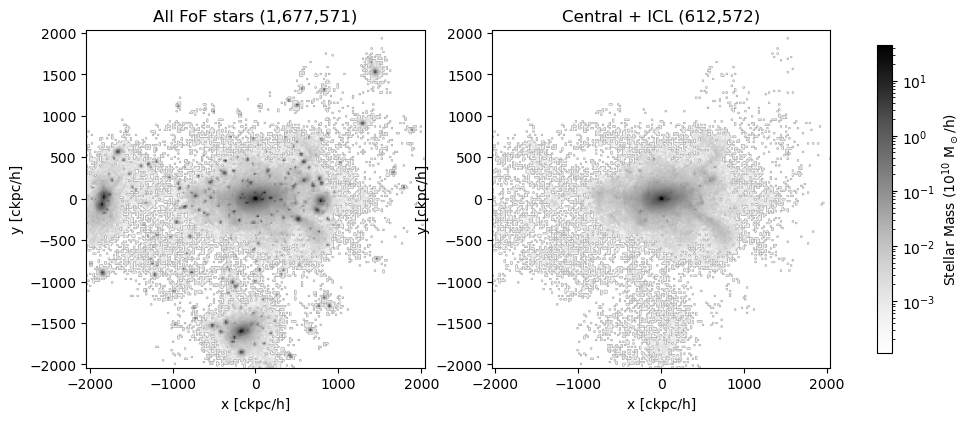

In [22]:
# Create 2D histograms
lim = np.percentile(np.abs(coords_stars[:, :2]), 99)
bins = [np.linspace(-lim, lim, 201), np.linspace(-lim, lim, 201)]

h_all, _, _ = np.histogram2d(coords_stars[:,1], coords_stars[:,2], bins=bins, weights=masses_stars)
h_cen, _, _ = np.histogram2d(coords_stars[central_mask,1], coords_stars[central_mask,2],
                              bins=bins, weights=masses_stars[central_mask])

# Common normalisation
vmin = min(h_all[h_all>0].min(), h_cen[h_cen>0].min())
vmax = max(h_all.max(), h_cen.max())
norm = colors.LogNorm(vmin=vmin, vmax=vmax)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, h, title in zip(axes, [h_all, h_cen],
                        [f'All FoF stars ({len(masses_stars):,})',
                         f'Central + ICL ({np.sum(central_mask):,})']):
    im = ax.imshow(h.T, origin='lower', extent=[-lim, lim, -lim, lim], cmap='Greys', norm=norm)
    ax.set_xlabel('x [ckpc/h]')
    ax.set_ylabel('y [ckpc/h]')
    ax.set_title(title)
    ax.set_aspect('equal')

fig.colorbar(im, ax=axes, label=r'Stellar Mass ($10^{10}$ M$_\odot$/h)', shrink=0.8)

---

# Part 5: Computing Observable Quantities

Simulations give us physical quantities (masses, positions), but TNG also provides forward-modelled photometry that can be compared with observations.

### Stellar photometry

The `GFM_StellarPhotometrics` field contains absolute magnitudes in 8 bands:

| Index | Band | System |
|-------|------|--------|
| 0 | U | Vega |
| 1 | B | Vega |
| 2 | V | Vega |
| 3 | K | Vega |
| 4 | g | AB (SDSS) |
| 5 | r | AB (SDSS) |
| 6 | i | AB (SDSS) |
| 7 | z | AB (SDSS) |

These are rest-frame magnitudes without dust attenuation.

### Converting to observables

To compare with observations, we need to place the simulated cluster at a realistic redshift and convert to observable units.

To keep things more observationally motivated, we'll use the projected stellar distribution and compute surface brightness in elliptical annuli aligned with the major axis.

**Limitations:** The `GFM_StellarPhotometrics` field provides rest-frame magnitudes. Here we simply add a distance modulus, which is valid at low redshift where the k-correction is small. At higher redshifts, we would need to apply k-corrections or re-compute the photometry in the observed frame using stellar population synthesis.

In [23]:
# r-band absolute magnitudes (index 5) -> flux at the configured observed redshift
h_hub    = sim_meta['hubble']
dist_mod = Planck15.distmod(Z_OBS).value
r_flux   = 10**(-0.4 * (photometrics[:, 5] + dist_mod))

# Convert coordinates to arcsec
d_A             = Planck15.angular_diameter_distance(Z_OBS).to(u.kpc).value
kpch_per_arcsec = d_A * h_hub * (np.pi / 180 / 3600)
x_arcsec        = coords_stars[:, 1] / kpch_per_arcsec
y_arcsec        = coords_stars[:, 2] / kpch_per_arcsec

# Mass-weighted shape tensor (central only)
m_cen    = masses_stars[central_mask]
x_cen, y_cen = x_arcsec[central_mask], y_arcsec[central_mask]
I = np.array([[np.sum(m_cen * x_cen**2),         np.sum(m_cen * x_cen * y_cen)],
              [np.sum(m_cen * x_cen * y_cen), np.sum(m_cen * y_cen**2)]]) / np.sum(m_cen)
eigenvalues, eigenvectors = np.linalg.eigh(I)

q  = np.sqrt(eigenvalues[0] / eigenvalues[1])           # axis ratio b/a
pa = np.arctan2(eigenvectors[1, 1], eigenvectors[0, 1]) # position angle

# Semi-major axis distance
x_rot = x_arcsec * np.cos(pa) + y_arcsec * np.sin(pa)
y_rot = -x_arcsec * np.sin(pa) + y_arcsec * np.cos(pa)
r_sma = np.sqrt(x_rot**2 + (y_rot / q)**2)

print(f"Object placed at z = {Z_OBS}")
print(f"  Distance modulus           : {dist_mod:.2f} mag")
print(f"  Angular diameter distance  : {d_A:.1f} kpc")
print(f"  Scale                      : {1/kpch_per_arcsec:.2f} arcsec per ckpc/h")
print(f"  Shape: q = {q:.3f}, PA = {np.degrees(pa):.1f} deg")


Object placed at z = 0.05
  Distance modulus           : 36.81 mag
  Angular diameter distance  : 208279.1 kpc
  Scale                      : 1.46 arcsec per ckpc/h
  Shape: q = 0.649, PA = -173.6 deg


### Surface brightness profile

We bin particles by semi-major axis and sum the flux in each elliptical annulus. Comparing the profile with and without satellites shows how much light comes from the central galaxy versus infalling systems. The inset shows the flux-weighted image of the central galaxy with ellipses at 1, 2, and 3 times the RMS semi-major axis.

In [24]:
def calc_sb_profile(r, flux, q=1, n_particles=5000):
    """Surface brightness profile in elliptical (or circular if q=1) annuli."""
    idx = np.argsort(r)
    r_sorted, flux_sorted = r[idx], flux[idx]
    n_bins = len(r) // n_particles

    r_mid, sb = np.zeros(n_bins), np.zeros(n_bins)
    for i in range(n_bins):
        r_in, r_out = r_sorted[i*n_particles], r_sorted[(i+1)*n_particles - 1]
        r_mid[i] = np.sqrt(r_in * r_out)
        sb[i] = -2.5 * np.log10(flux_sorted[i*n_particles:(i+1)*n_particles].sum() / (np.pi * q * (r_out**2 - r_in**2)))
    return r_mid, sb

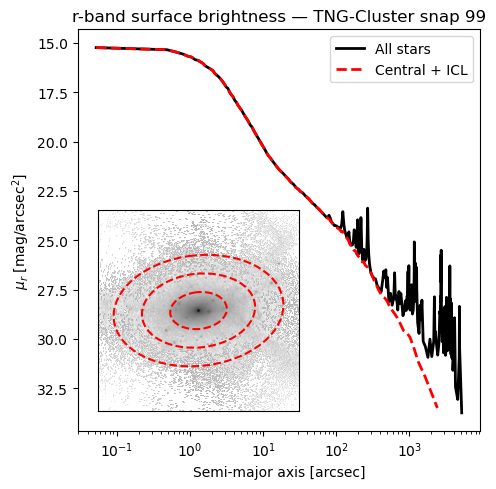

In [25]:
# Calculate profiles
r_all, sb_all = calc_sb_profile(r_sma, r_flux, q)
r_cen, sb_cen = calc_sb_profile(r_sma[central_mask], r_flux[central_mask], q)

# Plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.semilogx(r_all, sb_all, 'k-', lw=2, label='All stars')
ax.semilogx(r_cen, sb_cen, 'r--', lw=2, label='Central + ICL')
ax.set_xlabel('Semi-major axis [arcsec]')
ax.set_ylabel(r'$\mu_r$ [mag/arcsec$^2$]')
ax.set_title(f'r-band surface brightness — {SIM_NAME} snap {SNAP}')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()

# Inset image
ax_inset = ax.inset_axes([0.05, 0.05, 0.5, 0.5])
lim = np.percentile(np.abs(coords_stars[central_mask, :2]), 99) / kpch_per_arcsec  # in arcsec
bins = [np.linspace(-lim, lim, 201), np.linspace(-lim, lim, 201)]

h, _, _ = np.histogram2d(x_arcsec[central_mask], y_arcsec[central_mask], bins=bins, weights=r_flux[central_mask])
ax_inset.imshow(h.T, origin='lower', extent=[-lim, lim, -lim, lim],
          cmap='Greys', norm=colors.LogNorm())

# Add ellipses at 1, 2, 3 × RMS semi-major axis
a_rms = np.sqrt(eigenvalues[1])  # RMS semi-major axis in arcsec
for n in [1, 2, 3]:
    ellipse = Ellipse((0, 0), width=2*n*a_rms, height=2*n*a_rms*q,
                       angle=np.degrees(pa), fill=False, color='r', lw=1.5, ls='--')
    ax_inset.add_patch(ellipse)

ax_inset.set_xticks([])
ax_inset.set_yticks([])
ax_inset.set_aspect('equal')

plt.tight_layout()

---

# Part 6: Merger Trees

So far, we've looked at a single snapshot. To study evolution, we need to **link objects across snapshots**. This is what merger trees do.

### The challenge

At each snapshot, the structure finder identifies halos and subhalos independently. But how do we know that "subhalo 12345 at snapshot 99" is the same object as "subhalo 11000 at snapshot 98"? The IDs are not preserved between snapshots.

### How merger trees work

Merger tree algorithms track particles between snapshots: for each subhalo at snapshot N, find where its particles end up at snapshot N+1. The subhalo receiving the most particles (weighted by binding energy) is the **descendant**. Working backwards, the most massive progenitor at each step defines the **main progenitor branch**.

### Terminology

| Term | Definition |
|------|------------|
| **Descendant** | The object a subhalo evolves into at the next snapshot |
| **Progenitor** | An object that contributes to a subhalo at a previous snapshot |
| **Main progenitor branch** | Following the most massive progenitor back in time |
| **Merger** | When a secondary progenitor joins the main branch |

### Using the merger tree to track halos

The merger tree tracks the central **subhalo**, but also records which **FoF group** it belonged to at each snapshot (via `SubhaloGrNr`). This lets us load the FoF halo at any snapshot in the tree.

In [26]:
# Download the main progenitor branch (MPB) merger tree
print(f"Downloading merger tree for subhalo {central_subhalo_id} in {SIM_NAME}...")

mpb_file = get_with_backup(
    baseUrl + f'{SIM_NAME}/snapshots/{SNAP}/subhalos/{central_subhalo_id}/sublink/mpb.hdf5',
    backup_filename=f'mpb-{SIM_NAME}-{SNAP}-sub{central_subhalo_id}.hdf5'
)

print(f"Downloaded: {mpb_file}")


Downloaded: sublink_mpb_6677874.hdf5


In [27]:
# Load merger tree data
with h5py.File(mpb_file, 'r') as f:
    snap_nums = f['SnapNum'][:]
    subfind_ids = f['SubfindID'][:]
    group_ids = f['SubhaloGrNr'][:]  # FoF group ID at each snapshot
    m200c_tree = f['Group_M_Crit200'][:] * 1e10  # Msun/h
    stellar_mass_tree = f['SubhaloMassType'][:, 4] * 1e10  # Msun/h

print(f"Main progenitor branch: {len(snap_nums)} snapshots")
print(f"  From snapshot {snap_nums.min()} to {snap_nums.max()}")

Main progenitor branch: 98 snapshots
  From snapshot 2 to 99


In [28]:
# Get redshifts for each snapshot in the merger tree
print("Fetching snapshot redshifts...")
redshifts     = np.array([get(baseUrl + f'{SIM_NAME}/snapshots/{s}/')['redshift'] for s in snap_nums])
lookback_time = Planck15.lookback_time(redshifts).to(u.Gyr).value

print(f"  Redshift range : {redshifts.min():.2f} – {redshifts.max():.2f}")
print(f"  Lookback time  : {lookback_time.min():.1f} – {lookback_time.max():.1f} Gyr")


Fetching snapshot redshifts...
  Redshift range : 0.00 – 11.98
  Lookback time  : 0.0 – 13.4 Gyr


### Halo/subhalo IDs at each snapshot

The `GroupID` column can be used to load the FoF halo at any snapshot via the API.

In [29]:
# Print table of IDs
print(f"{'Snap':<6}{'z':<8}{'GroupID':<12}{'SubfindID':<12}{'log M200c':<12}{'log M*':<12}")
print("-"*62)
for i in range(4, len(snap_nums), 5):  # Every 5th row
    print(f"{snap_nums[i]:<6}{redshifts[i]:<8.2f}{group_ids[i]:<12}{subfind_ids[i]:<12}"
          f"{np.log10(m200c_tree[i]):<12.2f}{np.log10(stellar_mass_tree[i]):<12.2f}")

Snap  z       GroupID     SubfindID   log M200c   log M*      
--------------------------------------------------------------
95    0.05    12595516    6839332     14.56       12.51       
90    0.11    12669812    7040323     14.55       12.50       
85    0.18    12730167    7272423     14.55       12.49       
80    0.26    12802050    7535483     14.53       12.49       
75    0.35    12866580    7817181     14.45       12.46       
70    0.44    12925229    8114042     14.36       12.44       
65    0.55    13003627    8449689     14.31       12.43       
60    0.68    13116687    8847583     14.34       12.34       
55    0.82    13262684    9262521     14.36       12.33       
50    1.00    13388561    9770079     14.23       12.26       
45    1.21    13547975    10314318    13.88       12.21       
40    1.50    13763845    10987828    13.78       12.20       
35    1.82    14012734    11616470    13.72       12.19       
30    2.32    14287126    12295207    13.55       12.13

### Mass assembly history

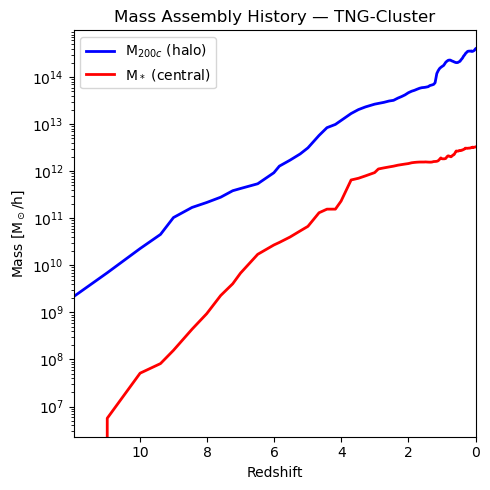

In [30]:
# Plot mass assembly
fig, ax = plt.subplots(figsize=(5, 5))

ax.semilogy(redshifts, m200c_tree, 'b-', lw=2, label=r'M$_{200c}$ (halo)')
ax.semilogy(redshifts, stellar_mass_tree, 'r-', lw=2, label=r'M$_*$ (central)')

ax.set_xlabel('Redshift')
ax.set_ylabel(r'Mass [M$_\odot$/h]')
ax.set_xlim(redshifts.max(), 0)
ax.set_title(f'Mass Assembly History — {SIM_NAME}')
ax.legend()
plt.tight_layout()

---

# Summary

In this tutorial, we've learned how to:

1. **Access simulation data** via web APIs
2. **Navigate the data hierarchy**: simulations → snapshots → halos → subhalos → particles
3. **Use the group catalog** to select objects and get integrated properties
4. **Download particle cutouts** for detailed analysis
5. **Separate central galaxies from satellites** using particle ordering
6. **Compute observable quantities** like surface brightness profiles
7. **Use merger trees** to track objects across cosmic time

### Key concepts

- **Snapshots** are time slices of the simulation
- **Halos** (FoF) contain **subhalos** (SUBFIND), which host galaxies
- The **central subhalo** is the main galaxy; others are **satellites**
- **Fuzz** particles are bound to the halo but not to any subhalo (e.g., ICL)
- Always filter out **wind particles** when analysing stars
- **Merger trees** link objects across snapshots

### Further resources

- [TNG Project documentation](https://www.tng-project.org/data/docs/)
- [Data specifications](https://www.tng-project.org/data/docs/specifications/)
- [API documentation](https://www.tng-project.org/data/docs/api/)